In [1]:
# Homework 6 Template
# G. Besla & R. Li
#Laine Kowalski

In [3]:
# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# my modules
from ReadFile import Read
# Step 1: modify CenterOfMass so that COM_P now takes a parameter specifying 
# by how much to decrease RMAX instead of a factor of 2
from CenterOfMass2 import CenterOfMass




In [34]:
def OrbitCOM(galaxy, start, end, n):
    """function that loops over all the desired snapshots to compute the COM pos and vel as a function of time.
    inputs:
          
    outputs: 
    """
    
    # compose the filename for output
    fileout = f"Orbit_{galaxy}.txt" #this is more specific for which ever file is being read in
    
    #  set tolerance and VolDec for calculating COM_P in CenterOfMass
    delta = 0.1
    volDec = 2
    
    # for M33 that is stripped more, use different values for VolDec
    if galaxy == "M33":
        volDec=4
    
    # generate the snapshot id sequence 
    # it is always a good idea to also check if the input is eligible (not required)
    snap_ids = np.arange(start,end,n) #orbits up to Snapshot n in intervals 
    
    #Quick test -
    if snap_ids.size == 0:
        raise ValueError("snap_ids was empty") #let's user knows something went wrong
        
    # initialize the array for orbital info: t, x, y, z, vx, vy, vz of COM
    orbit = np.zeros(((end-start)//n,7))
    
    # a for loop 
    for i, snap_id in enumerate(snap_ids): # loop over files
        
        #files all went into separate folders 
        # compose the data filename (be careful about the folder)
        ilbl = '000' + str(snap_id)
        # remove all but the last 3 digits
        ilbl = ilbl[-3:]
        filename=f"{galaxy}/{galaxy}_{ilbl}.txt"
        
        # Initialize an instance of CenterOfMass class, using disk particles
        COM = CenterOfMass(filename, 2) #initializing instance, 2 for disk particles

        # Store the COM pos and vel. Remember that now COM_P required VolDec
        # store the position and velocity COM
        COM_p = COM.COM_P(delta,volDec)
        COM_v = COM.COM_V(COM_p[0], COM_p[1], COM_p[2]) #takes 3 positions from CM
    
        # store the time, pos, vel in ith element of the orbit array,  without units (.value) 
        # note that you can store 
        # a[i] = var1, *tuple(array1)


        # print snap_id to see the progress
        print(snap_id)
        orbit[i,0] = COM.time.value/1000 #for all rows in 0th column, put time 
        orbit[i,1] = COM_p[0].value #.value because don't want the unit
        orbit[i,2] = COM_p[1].value
        orbit[i,3] = COM_p[2].value
        
        #For velocity:
        orbit[i,4] = COM_v[0].value
        orbit[i,5] = COM_v[1].value
        orbit[i,6] = COM_v[2].value
                
    # write the data to a file
    # we do this because we don't want to have to repeat this process 
    # this code should only have to be called once per galaxy.
    np.savetxt(fileout, orbit, fmt = "%11.3f"*7, comments='#',
               header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                      .format('t', 'x', 'y', 'z', 'vx', 'vy', 'vz'))

In [46]:
# Recover the orbits and generate the COM files for each galaxy
# read in 800 snapshots in intervals of n=5
# Note: This might take a little while - test your code with a smaller number of snapshots first! 
OrbitCOM(galaxy="MW", start=0, end=800, n=5) #Test MW
OrbitCOM(galaxy="M31", start=0, end=800, n=5)#Test M31 
OrbitCOM(galaxy="M33", start=0, end=800, n=5)#Test M33

0
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255
260
265
270
275
280
285
290
295
300
305
310
315
320
325
330
335
340
345
350
355
360
365
370
375
380
385
390
395
400
405
410
415
420
425
430
435
440
445
450
455
460
465
470
475
480
485
490
495
500
505
510
515
520
525
530
535
540
545
550
555
560
565
570
575
580
585
590
595
600
605
610
615
620
625
630
635
640
645
650
655
660
665
670
675
680
685
690
695
700
705
710
715
720
725
730
735
740
745
750
755
760
765
770
775
780
785
790
795
0
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255
260
265
270
275
280
285
290
295
300
305
310
315
320
325
330
335
340
345
350
355
360
365
370
375
380
385
390
395
400
405
410
415
420
425
430
435
440
445
450
455
460
465
470
475
480
485
490
495
500


In [47]:
# Read in the data files for the orbits of each galaxy that you just created
# headers:  t, x, y, z, vx, vy, vz
# using np.genfromtxt

MW_Orbit = np.genfromtxt("Orbit_MW.txt") 
M31_Orbit = np.genfromtxt("Orbit_M31.txt")
M33_Orbit = np.genfromtxt("Orbit_M33.txt")

In [48]:
# function to compute the magnitude of the difference between two vectors 
# You can use this function to return both the relative position and relative velocity for two 
# galaxies over the entire orbit  


def VectorDiff(v1, v2):
    '''This function will compute the magnitude of the difference between two vectors 
    Input: v1, v2 -> two vectors
    Outpit: the magnitude of the differenece between vectors
    '''
    diff = v1-v2 #subtracting vectors
    mag = np.sqrt(diff[:,0]**2+diff[:,1]**2+diff[:,2]**2) #getting vector mags
    
    return mag

In [49]:
# Determine the magnitude of the relative position and velocities 

#For Positions:
# of MW and M31
MW_M31_rel_pos = VectorDiff(MW_Orbit[:, 1:4],M31_Orbit[:, 1:4])

# of M33 and M31
M33_M31_rel_pos = VectorDiff(M31_Orbit[:, 1:4],M33_Orbit[:, 1:4])


#For velocities:
# of MW and M31
MW_M31_rel_vel = VectorDiff(MW_Orbit[:,4:],M31_Orbit[:,4:])

# of M33 and M31
M33_M31_rel_vel = VectorDiff(M31_Orbit[:,4:],M33_Orbit[:,4:])

In [50]:
print(MW_M31_rel_pos) #4 numbers printed - checking vector diff function

[7.69120299e+02 7.61115872e+02 7.52887097e+02 7.44309862e+02
 7.35605632e+02 7.26920019e+02 7.17789942e+02 7.08555289e+02
 6.99603077e+02 6.90879781e+02 6.82590113e+02 6.74300445e+02
 6.65917757e+02 6.57727242e+02 6.49428408e+02 6.41853750e+02
 6.34022528e+02 6.26010148e+02 6.17788923e+02 6.09389545e+02
 6.00966103e+02 5.92220582e+02 5.83118594e+02 5.73604549e+02
 5.63682100e+02 5.53509158e+02 5.43263729e+02 5.32124769e+02
 5.20678008e+02 5.08763631e+02 4.96417790e+02 4.83728460e+02
 4.70871963e+02 4.57652695e+02 4.44160177e+02 4.30360690e+02
 4.15910429e+02 4.01218284e+02 3.86407789e+02 3.71308461e+02
 3.55537122e+02 3.39421263e+02 3.23254707e+02 3.05421461e+02
 2.87569643e+02 2.69242933e+02 2.50215343e+02 2.30390123e+02
 2.09593109e+02 1.87750452e+02 1.64822152e+02 1.40584183e+02
 1.14884109e+02 8.78579911e+01 6.04559592e+01 3.82741087e+01
 4.00961407e+01 6.19416605e+01 8.57967867e+01 1.06548195e+02
 1.23659073e+02 1.37633521e+02 1.48692607e+02 1.57441179e+02
 1.63981819e+02 1.691828

Text(0.5, 1.0, 'Position Separation of M33 and M31')

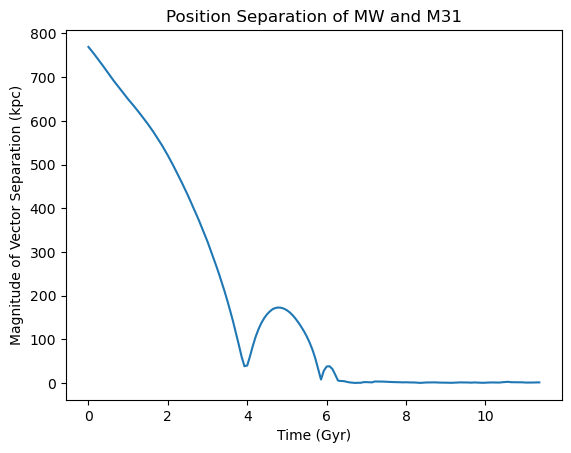

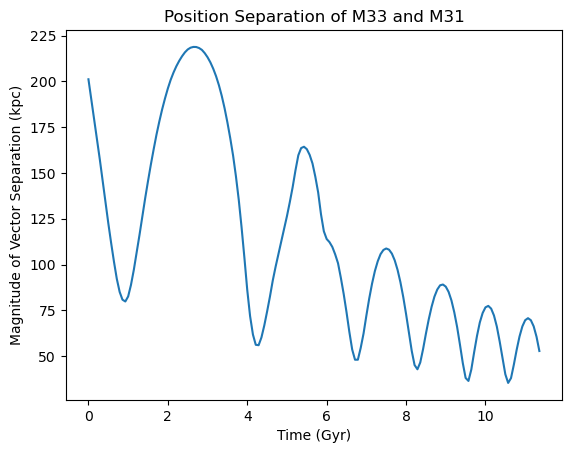

In [51]:
# Plot the Orbit of the galaxies 
#################################

#MW/M31 Position
fig,ax = plt.subplots()
ax.plot(MW_Orbit[:,0],MW_M31_rel_pos) #all of the times, already right length
plt.xlabel("Time (Gyr)")
plt.ylabel("Magnitude of Vector Separation (kpc)")
plt.title("Position Separation of MW and M31")

#M33/M31 Position
fig,ax = plt.subplots()
ax.plot(MW_Orbit[:,0],M33_M31_rel_pos) #all of the times, already right length
plt.xlabel("Time (Gyr)")
plt.ylabel("Magnitude of Vector Separation (kpc)")
plt.title("Position Separation of M33 and M31")



Text(0.5, 1.0, 'Velocity Separation of M33 and M31')

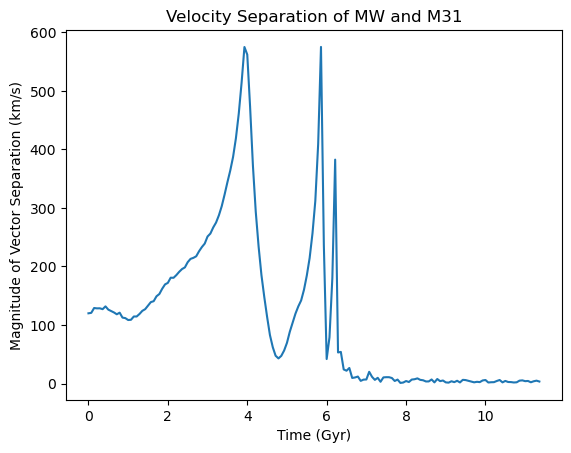

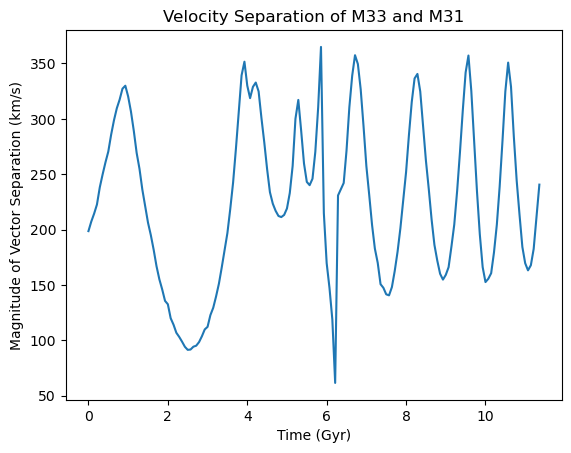

In [52]:
# Plot the orbital velocities of the galaxies 
#################################

#MW/M31 Velocity
fig,ax = plt.subplots()
ax.plot(MW_Orbit[:,0],MW_M31_rel_vel) #all of the times, already right length
plt.xlabel("Time (Gyr)")
plt.ylabel("Magnitude of Vector Separation (km/s)")
plt.title("Velocity Separation of MW and M31")

#M33/M31 Velocity
fig,ax = plt.subplots()
ax.plot(MW_Orbit[:,0],M33_M31_rel_vel) #all of the times, already right length
plt.xlabel("Time (Gyr)")
plt.ylabel("Magnitude of Vector Separation (km/s)")
plt.title("Velocity Separation of M33 and M31")

(6.0, 7.0)

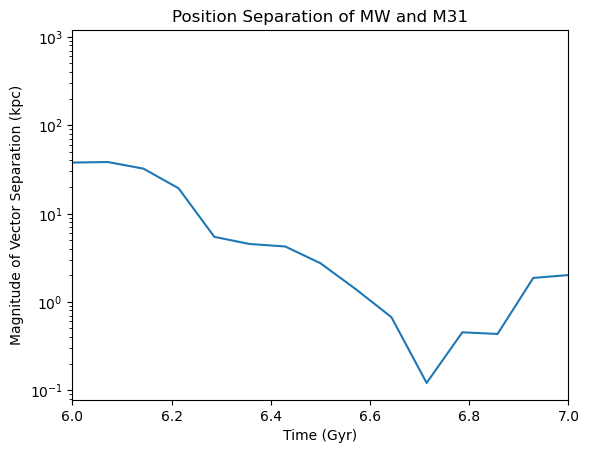

In [56]:
#MW/M31 Position - checking when they merge
fig,ax = plt.subplots()
ax.plot(MW_Orbit[:,0],MW_M31_rel_pos) #all of the times, already right length
plt.xlabel("Time (Gyr)")
plt.ylabel("Magnitude of Vector Separation (kpc)")
plt.title("Position Separation of MW and M31")
plt.semilogy()
ax.set_xlim(6,7)

In [ ]:
#Part 4: Questions

'''
1. How many close encounters will the MW and M31 experience in the future?

Based on the position graph for MW and M31, there will be 2 close encounters 
in the future as the galaxies collide. We know this by counting the troughs.
After this, it appears that the galaxies combine into 1.
'''

'''
2. How is the time evolution of the separation and relative velocity related?

When the separation is shorter/when they are closer, the relative velocity increases
mainly due to gravitational forces. 
'''

'''
3. When do M31 and the MW merge? (you might need to zoom in on the plot - try a log y axis). 
What happens to M33’s orbit when they merge?

Based on the semilog graph that I zoomed into, the minimum separation occurs
at the lowest trough. Therefore, they merge in around ~6.7 Gyr.
'''
